In [3]:
# 1. English dataset Macworld – FIXED for macOS

import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# YOUR EXACT MACOS PATH (from your screenshot)
# ────────────────────────────────────────────────────────────────
dataset_path = "/Users/rexogehenerobo/Downloads/My Repo’s/DataAnalytics/Datasets/macworld"

# Tags to analyse (unchanged)
tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords"]

# Text cleaning function (unchanged – good)
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# Function to count keyword occurrences (with safe debug – no DEBUG variable)
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")  # Show first 200 chars
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

# Initialize counters
total_tag_counts = {tag: 0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of Macworld Dataset...\n")
print(f"Using path: {dataset_path}")
if not os.path.exists(dataset_path):
    print(f"ERROR: Folder not found! Please check: {dataset_path}")
else:
    print(f"Folder found – proceeding...")

# Loop through dataset folders
for folder_name in os.listdir(dataset_path):
    folder_full_path = os.path.join(dataset_path, folder_name)
    
    if not os.path.isdir(folder_full_path):
        continue
    
    html_file = os.path.join(folder_full_path, "index.html")
    tags_file = os.path.join(folder_full_path, "tags.txt")
    
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # ────────────────────────────────────────────────────────────────
        # IMPROVED KEYWORD READING – fixes empty list problem
        # ────────────────────────────────────────────────────────────────
        with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
            raw_content = f.read().strip().lower()
            # Remove leading number + optional space/comma
            raw_content = re.sub(r'^\d+[\s,]*', '', raw_content).strip()
            
            # Split: try comma first, then space/newline
            if ',' in raw_content:
                keywords = [k.strip() for k in raw_content.split(',') if k.strip()]
            else:
                keywords = [k.strip() for k in re.split(r'[\s\n]+', raw_content) if k.strip()]
            
            keywords = list(set(keywords))  # remove duplicates
            
            # Always show result (so we know if parsing works)
            print(f"[{folder_name}] → {len(keywords)} keywords extracted: {keywords[:8]}{'...' if len(keywords)>8 else ''}")
            
            if not keywords:
                print("  WARNING: No keywords found – skipping this article")
                continue
        
        # Read and parse HTML
        with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "lxml")
        
        # Remove script/style elements
        for script_or_style in soup(["script", "style"]):
            script_or_style.decompose()
        
        # Extract text from HTML tags
        tags_data = {
            "title": [soup.title.get_text()] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            "h2": [h.get_text() for h in soup.find_all("h2")],
            "h3": [h.get_text() for h in soup.find_all("h3")],
            "h4": [h.get_text() for h in soup.find_all("h4")],
            "p": [p.get_text() for p in soup.find_all("p")],
            "a": [a.get_text() for a in soup.find_all("a")],
            "strong": [s.get_text() for s in soup.find_all("strong")],
            "em": [e.get_text() for e in soup.find_all("em")],
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name":"keywords"})]
        }
        
        # Show debug for first folder only (controlled)
        show_debug = (processed_folders == 0)
        
        # Count keywords per tag
        for tag in tags_to_check:
            count = count_keywords(tags_data[tag], keywords, tag, folder_name, debug=show_debug)
            total_tag_counts[tag] += count
            if count > 0 and show_debug:
                print(f"   {tag}: {count} matches")
        
        if processed_folders == 0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders += 1
        if processed_folders % 20 == 0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag", "Keyword Occurrences"])

if df["Keyword Occurrences"].sum() > 0:
    df["Percentage"] = (df["Keyword Occurrences"] / df["Keyword Occurrences"].sum()) * 100
    df = df.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    df["Importance Score"] = df["Keyword Occurrences"] / df["Keyword Occurrences"].max()
    print("\n" + df.to_string())
    
    # Visualization
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"], df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("Macworld Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check:")
    print("1. Path:", dataset_path)
    print("2. tags.txt files contain keywords")
    print("3. Run the debug prints above to see if keywords are extracted")

Starting analysis of Macworld Dataset...

Using path: /Users/rexogehenerobo/Downloads/My Repo’s/DataAnalytics/Datasets/macworld
ERROR: Folder not found! Please check: /Users/rexogehenerobo/Downloads/My Repo’s/DataAnalytics/Datasets/macworld


FileNotFoundError: [Errno 2] No such file or directory: '/Users/rexogehenerobo/Downloads/My Repo’s/DataAnalytics/Datasets/macworld'

Starting analysis of IndianExpress Dataset...


--- DEBUG: article--blogs--kumari-selja-isnt-indias-enemy-the-abhorrent-caste-system-is-- | Tag: <title> ---
CLEANED WORDS: dictum diaspora kumari selja isn t india s enemy the abhorrent caste system is the indian express...
   [Match] 'india' found 1 times
   [Match] 'caste system' found 1 times
   [Match] 'kumari selja' found 1 times

--- DEBUG: article--blogs--kumari-selja-isnt-indias-enemy-the-abhorrent-caste-system-is-- | Tag: <h1> ---
CLEANED WORDS: dictum diaspora kumari selja isn t india s enemy the abhorrent caste system is...
   [Match] 'india' found 1 times
   [Match] 'caste system' found 1 times
   [Match] 'kumari selja' found 1 times

--- DEBUG: article--blogs--kumari-selja-isnt-indias-enemy-the-abhorrent-caste-system-is-- | Tag: <h2> ---
CLEANED WORDS: one must admit that the successive congress and the bjp regimes have done little to fight the caste system...
   [Match] 'caste system' found 1 times

--- DEBUG: article--blog


Review the found words above, then press Enter to continue full analysis... 


> 20 folders processed...
> 40 folders processed...
> 60 folders processed...
> 80 folders processed...
> 100 folders processed...
> 120 folders processed...
> 140 folders processed...
> 160 folders processed...
> 180 folders processed...
> 200 folders processed...
> 220 folders processed...
> 240 folders processed...
> 260 folders processed...
> 280 folders processed...
> 300 folders processed...
> 320 folders processed...

--- Analysis Completed: 329 pages analysed ---

        HTML Tag  Keyword Occurrences  Percentage  Importance Score
0              p                 2101   29.826803          1.000000
1              a                 2032   28.847246          0.967158
2  meta_keywords                 1811   25.709824          0.861970
3          title                  388    5.508234          0.184674
4             h1                  387    5.494037          0.184198
5             h2                  281    3.989211          0.133746
6         strong                   28    0.3975

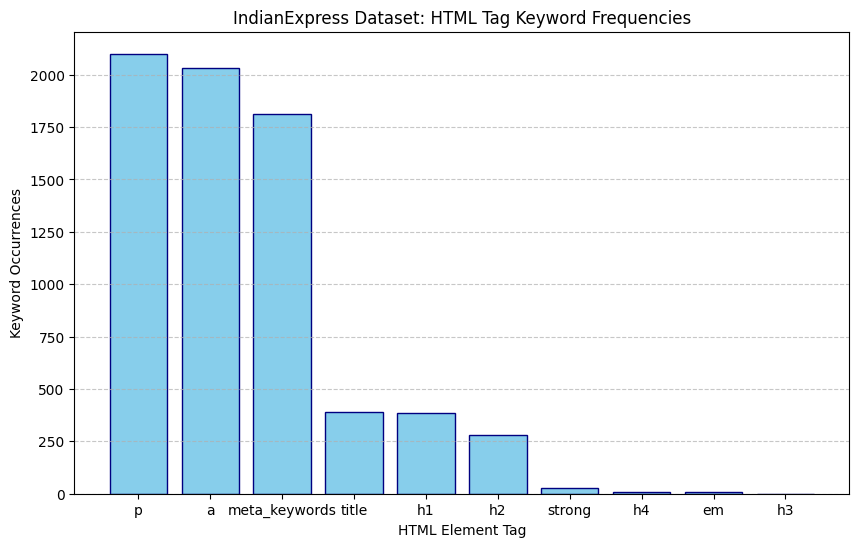

In [ ]:
# 2. English dataset IndianExpress (Debug + Keyword Reporting) – FIXED for macOS

import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# YOUR EXACT MACOS PATH (from your screenshot)
# ────────────────────────────────────────────────────────────────
dataset_path = "/Users/rexogehenerobo/Downloads/My Repo’s/DataAnalytics/Datasets/indianexpress"

# Tags to analyse (unchanged)
tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords"]

# Text cleaning function (unchanged – good)
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# Function to count keyword occurrences (with safe debug – no DEBUG variable)
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")  # Show first 200 chars
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

# Initialize counters
total_tag_counts = {tag: 0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of IndianExpress Dataset...\n")
print(f"Using path: {dataset_path}")
if not os.path.exists(dataset_path):
    print(f"ERROR: Folder not found! Please check: {dataset_path}")
else:
    print(f"Folder found – proceeding...")

# Loop through dataset folders
for folder_name in os.listdir(dataset_path):
    folder_full_path = os.path.join(dataset_path, folder_name)
    
    if not os.path.isdir(folder_full_path):
        continue
    
    html_file = os.path.join(folder_full_path, "index.html")
    tags_file = os.path.join(folder_full_path, "tags.txt")
    
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # ────────────────────────────────────────────────────────────────
        # IMPROVED KEYWORD READING – fixes empty list problem
        # ────────────────────────────────────────────────────────────────
        with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
            raw_content = f.read().strip().lower()
            # Remove leading number + optional space/comma
            raw_content = re.sub(r'^\d+[\s,]*', '', raw_content).strip()
            
            # Split: try comma first, then space/newline
            if ',' in raw_content:
                keywords = [k.strip() for k in raw_content.split(',') if k.strip()]
            else:
                keywords = [k.strip() for k in re.split(r'[\s\n]+', raw_content) if k.strip()]
            
            keywords = list(set(keywords))  # remove duplicates
            
            # Always show result
            print(f"[{folder_name}] → {len(keywords)} keywords extracted: {keywords[:8]}{'...' if len(keywords)>8 else ''}")
            
            if not keywords:
                print("  WARNING: No keywords found – skipping this article")
                continue
        
        # Read and parse HTML
        with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "lxml")
        
        # Remove script/style elements
        for script_or_style in soup(["script", "style"]):
            script_or_style.decompose()
        
        # Extract text from HTML tags
        tags_data = {
            "title": [soup.title.get_text()] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            "h2": [h.get_text() for h in soup.find_all("h2")],
            "h3": [h.get_text() for h in soup.find_all("h3")],
            "h4": [h.get_text() for h in soup.find_all("h4")],
            "p": [p.get_text() for p in soup.find_all("p")],
            "a": [a.get_text() for a in soup.find_all("a")],
            "strong": [s.get_text() for s in soup.find_all("strong")],
            "em": [e.get_text() for e in soup.find_all("em")],
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name":"keywords"})]
        }
        
        # Show debug for first folder only
        show_debug = (processed_folders == 0)
        
        # Count keywords per tag
        for tag in tags_to_check:
            count = count_keywords(tags_data[tag], keywords, tag, folder_name, debug=show_debug)
            total_tag_counts[tag] += count
            if count > 0 and show_debug:
                print(f"   {tag}: {count} matches")
        
        if processed_folders == 0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders += 1
        if processed_folders % 20 == 0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag", "Keyword Occurrences"])

if df["Keyword Occurrences"].sum() > 0:
    df["Percentage"] = (df["Keyword Occurrences"] / df["Keyword Occurrences"].sum()) * 100
    df = df.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    df["Importance Score"] = df["Keyword Occurrences"] / df["Keyword Occurrences"].max()
    print("\n" + df.to_string())
    
    # Visualization
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"], df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("IndianExpress Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check:")
    print("1. Path:", dataset_path)
    print("2. tags.txt files contain keywords")
    print("3. Run the debug prints above to see if keywords are extracted")

Starting analysis of Kaksplus Dataset...


--- DEBUG: 2013--08--29--unikoulu-opettaa-vauvalle-unirytmin-- | Tag: <title> ---
CLEANED WORDS: unikoulu opettaa unirytmin kaksplus fi...
   [Match] 'unikoulu' found 1 times

--- DEBUG: 2013--08--29--unikoulu-opettaa-vauvalle-unirytmin-- | Tag: <h1> ---
CLEANED WORDS: unikoulu opettaa unirytmin...
   [Match] 'unikoulu' found 1 times

--- DEBUG: 2013--08--29--unikoulu-opettaa-vauvalle-unirytmin-- | Tag: <h2> ---
CLEANED WORDS: tuolikoulu toimii perhepetikin ok sairaudet suljettava pois avainsanat kommentit suosittelemme sinulle keskusteluissa yhteistyössä tilaa uutiskirje oletko raskaana suosituimmat keskusteluissa mumfie...

--- DEBUG: 2013--08--29--unikoulu-opettaa-vauvalle-unirytmin-- | Tag: <h3> ---
CLEANED WORDS: peruuta vastaus äidin kehitysvaiheet tunnistatko itsesi unohdin imetyksen jälkeen tissin esille ja muut väsyneiden äitien noloimmat mokat oletko virallinen valmentaja vai kaksisormilaiskiainen testaa ...
   [Match] 'vauva' found 


Review the found words above, then press Enter to continue full analysis... 


> 20 folders processed...
> 40 folders processed...
> 60 folders processed...
> 80 folders processed...
> 100 folders processed...
> 120 folders processed...
> 140 folders processed...
> 160 folders processed...
> 180 folders processed...
> 200 folders processed...

--- Analysis Completed: 200 pages analysed ---
        HTML Tag  Keyword Occurrences  Percentage  Importance Score
0              a                 1674   50.391331          1.000000
1              p                 1123   33.804937          0.670848
2             h1                  150    4.515352          0.089606
3          title                  138    4.154124          0.082437
4             h2                  136    4.093919          0.081243
5             h3                   44    1.324503          0.026284
6         strong                   30    0.903070          0.017921
7             em                   27    0.812763          0.016129
8             h4                    0    0.000000          0.000000
9  met

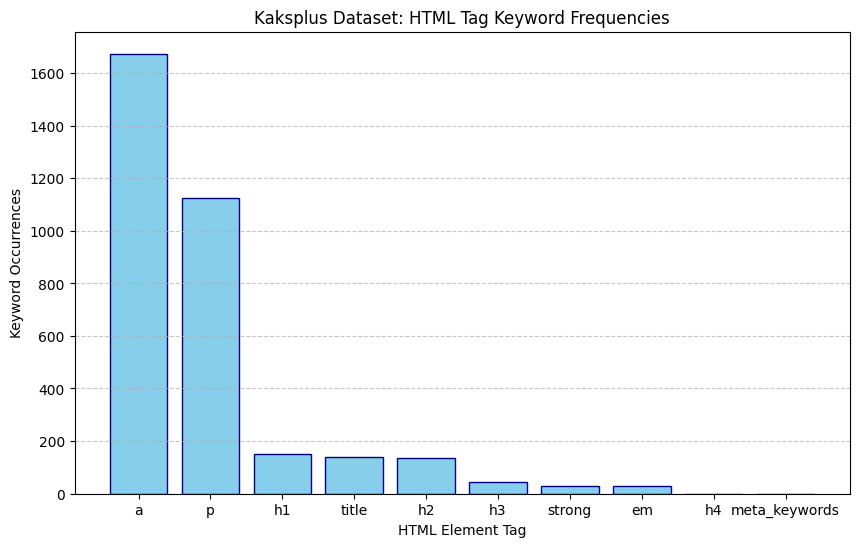

In [ ]:
# 3. Finnish dataset Kaksplus – FIXED for macOS

import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# YOUR EXACT MACOS PATH (from your screenshot)
# ────────────────────────────────────────────────────────────────
dataset_path = "/Users/rexogehenerobo/Downloads/My Repo’s/DataAnalytics/Datasets/kaksplus"

# Tags to analyse (unchanged)
tags_to_check = ["title","h1","h2","h3","h4","p","a","strong","em","meta_keywords"]

# Text cleaning function (unchanged – good)
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# Function to count keyword occurrences (with safe debug – no DEBUG variable)
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")  # Show first 200 chars
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

# Initialize counters
total_tag_counts = {tag: 0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of Kaksplus Dataset...\n")
print(f"Using path: {dataset_path}")
if not os.path.exists(dataset_path):
    print(f"ERROR: Folder not found! Please check: {dataset_path}")
else:
    print(f"Folder found – proceeding...")

# Loop through folders
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    
    html_file = os.path.join(folder_path, "index.html")
    tags_file = os.path.join(folder_path, "tags.txt")
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # ────────────────────────────────────────────────────────────────
        # IMPROVED KEYWORD READING – fixes empty list problem
        # ────────────────────────────────────────────────────────────────
        with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
            raw_content = f.read().strip().lower()
            # Remove leading number + optional space/comma
            raw_content = re.sub(r'^\d+[\s,]*', '', raw_content).strip()
            
            # Split: try comma first, then space/newline
            if ',' in raw_content:
                keywords = [k.strip() for k in raw_content.split(',') if k.strip()]
            else:
                keywords = [k.strip() for k in re.split(r'[\s\n]+', raw_content) if k.strip()]
            
            keywords = list(set(keywords))  # remove duplicates
            
            # Always show result
            print(f"[{folder_name}] → {len(keywords)} keywords extracted: {keywords[:8]}{'...' if len(keywords)>8 else ''}")
            
            if not keywords:
                print("  WARNING: No keywords found – skipping this article")
                continue
        
        # Read HTML
        with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "lxml")
        
        # Extract tags
        tags_data = {
            "title": [soup.title.get_text()] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            "h2": [h.get_text() for h in soup.find_all("h2")],
            "h3": [h.get_text() for h in soup.find_all("h3")],
            "h4": [h.get_text() for h in soup.find_all("h4")],
            "p": [p.get_text() for p in soup.find_all("p")],
            "a": [a.get_text() for a in soup.find_all("a")],
            "strong": [s.get_text() for s in soup.find_all("strong")],
            "em": [e.get_text() for e in soup.find_all("em")],
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name":"keywords"})]
        }
        
        # Show debug for first folder
        show_debug = (processed_folders == 0)
        
        # Count keywords per tag
        for tag in tags_to_check:
            count = count_keywords(tags_data[tag], keywords, tag, folder_name, debug=show_debug)
            total_tag_counts[tag] += count
            if count > 0 and show_debug:
                print(f"   {tag}: {count} matches")
        
        if processed_folders == 0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders += 1
        if processed_folders % 20 == 0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag","Keyword Occurrences"])

if df["Keyword Occurrences"].sum() > 0:
    df["Percentage"]=(df["Keyword Occurrences"]/df["Keyword Occurrences"].sum())*100
    df=df.sort_values(by="Keyword Occurrences",ascending=False).reset_index(drop=True)
    df["Importance Score"]=df["Keyword Occurrences"]/df["Keyword Occurrences"].max()
    print(df.to_string())
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"],df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("Kaksplus Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check:")
    print("1. Path:", dataset_path)
    print("2. tags.txt files contain keywords")
    print("3. Run the debug prints above to see if keywords are extracted")

Starting analysis of Uusisuomi Dataset...


--- DEBUG: autot--102310-uusi-kiinalainen-rengasmerkki-tulossa-suomeen | Tag: <title> ---
CLEANED WORDS: uusi kiinalainen rengasmerkki tulossa suomeen uusi suomi...
   [Match] 'rengasmerkki' found 1 times

--- DEBUG: autot--102310-uusi-kiinalainen-rengasmerkki-tulossa-suomeen | Tag: <h1> ---
CLEANED WORDS: uusi kiinalainen rengasmerkki tulossa suomeen...
   [Match] 'rengasmerkki' found 1 times

--- DEBUG: autot--102310-uusi-kiinalainen-rengasmerkki-tulossa-suomeen | Tag: <h2> ---
CLEANED WORDS: hakulomake hakulomake päävalikko toissijainen valikko aiheita tänään tuoreimmat kommentit uuden suomen yrityskanava mainos autotodayn koeajot tuoreimmat autouutiset poiminnat uuden suomen blogit yrity...

--- DEBUG: autot--102310-uusi-kiinalainen-rengasmerkki-tulossa-suomeen | Tag: <h4> ---
CLEANED WORDS: autotoday testasi ford focus wagon titanium isomman oloinen tässä uusi suomi autot osion ensimmäisen vuoden suosituimmat koeajot autotoday testasi vw


Review the found words above, then press Enter to continue full analysis... 


> 20 folders processed...
> 40 folders processed...
> 60 folders processed...
> 80 folders processed...
> 100 folders processed...
> 120 folders processed...
> 140 folders processed...
> 160 folders processed...
> 180 folders processed...
> 200 folders processed...

--- Analysis Completed: 200 pages analysed ---
        HTML Tag  Keyword Occurrences  Percentage  Importance Score
0              a                 2438   61.210143          1.000000
1              p                 1021   25.633944          0.418786
2         strong                  223    5.598795          0.091468
3          title                  101    2.535777          0.041427
4             h1                  100    2.510670          0.041017
5             em                   46    1.154908          0.018868
6             h4                   44    1.104695          0.018048
7             h2                   10    0.251067          0.004102
8             h3                    0    0.000000          0.000000
9  met

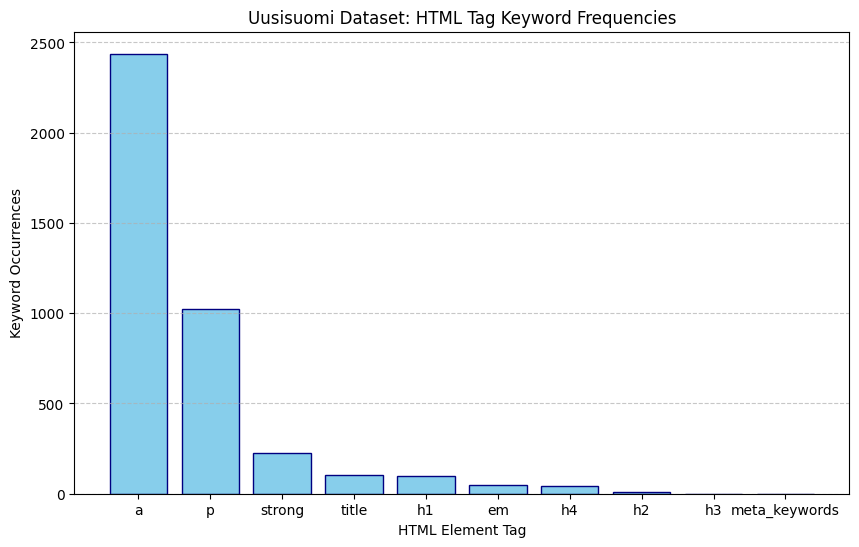

In [ ]:

# 2. Finnish dataset Uusisuomi 
import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# Dataset path
dataset_path = r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\uusisuomi"

# Tags to analyse
tags_to_check = ["title","h1","h2","h3","h4","p","a","strong","em","meta_keywords"]

# Text cleaning function
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# Function to count keyword occurrences (with debug)
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")  # Show first 200 chars
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

# Initialize counters
total_tag_counts = {tag:0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of Uusisuomi Dataset...\n")

# Loop through folders
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    
    html_file = os.path.join(folder_path,"index.html")
    tags_file = os.path.join(folder_path,"tags.txt")
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # Read keywords
        with open(tags_file,"r",encoding="utf-8",errors="ignore") as f:
            line = f.read().strip()
            parts = line.split(None,1)
            if len(parts)<2:
                continue
            keywords = [k.strip() for k in parts[1].split(",") if k.strip()]
        
        # Read HTML
        with open(html_file,"r",encoding="utf-8",errors="ignore") as f:
            soup = BeautifulSoup(f.read(),"lxml")
        
        # Extract tags
        tags_data = {
            "title":[soup.title.get_text()] if soup.title else [],
            "h1":[h.get_text() for h in soup.find_all("h1")],
            "h2":[h.get_text() for h in soup.find_all("h2")],
            "h3":[h.get_text() for h in soup.find_all("h3")],
            "h4":[h.get_text() for h in soup.find_all("h4")],
            "p":[p.get_text() for p in soup.find_all("p")],
            "a":[a.get_text() for a in soup.find_all("a")],
            "strong":[s.get_text() for s in soup.find_all("strong")],
            "em":[e.get_text() for e in soup.find_all("em")],
            "meta_keywords":[m["content"] for m in soup.find_all("meta",attrs={"name":"keywords"})]
        }
        
        # Show debug for first folder
        show_debug = True if processed_folders == 0 else False
        
        # Count keywords per tag
        for tag in tags_to_check:
            total_tag_counts[tag]+=count_keywords(tags_data[tag],keywords, tag, folder_name, debug=show_debug)
        
        if processed_folders==0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders+=1
        if processed_folders%20==0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()),columns=["HTML Tag","Keyword Occurrences"])

if df["Keyword Occurrences"].sum()>0:
    df["Percentage"]=(df["Keyword Occurrences"]/df["Keyword Occurrences"].sum())*100
    df=df.sort_values(by="Keyword Occurrences",ascending=False).reset_index(drop=True)
    df["Importance Score"]=df["Keyword Occurrences"]/df["Keyword Occurrences"].max()
    print(df.to_string())
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"],df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("Uusisuomi Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check tags.txt format.")

Starting analysis of German Dataset...


--- DEBUG: 0 | Tag: <title> ---
CLEANED WORDS: sprache bildung und erfolg neuere erkenntnisse aus der forschung die perspektive der bildungsforschung goethe institut...
   [Match] 'forschung' found 1 times
   [Match] 'bildung' found 1 times

--- DEBUG: 0 | Tag: <h1> ---
CLEANED WORDS: neuere erkenntnisse aus der forschung die perspektive der bildungsforschung sprache bildung und erfolg...
   [Match] 'forschung' found 1 times
   [Match] 'bildung' found 1 times

--- DEBUG: 0 | Tag: <h2> ---
CLEANED WORDS: deutsche sprache sprache und herkunft felder der bildungsforschung...

--- DEBUG: 0 | Tag: <h3> ---
CLEANED WORDS: anmeldung deutsche sprache kultur über uns autorin links zum thema standpunkte...

--- DEBUG: 0 | Tag: <h4> ---
CLEANED WORDS: magazin sprache deutschkurse und deutschprüfungen deutsch unterrichten kostenlos deutsch üben unser engagement für deutsch warum deutsch lernen willkommen deutschlernen für flüchtlinge europa architek...
   [


Review the cleaned words above, then press Enter to finish the full analysis... 


> 20 folders processed...
> 40 folders processed...
> 60 folders processed...
> 80 folders processed...

--- Analysis Completed: 86 pages analysed ---

        HTML Tag  Keyword Occurrences  Percentage  Importance Score
0  meta_keywords                 3123   34.800535          1.000000
1              a                 2845   31.702697          0.910983
2              p                 1505   16.770671          0.481908
3             h3                  471    5.248496          0.150817
4          title                  393    4.379318          0.125841
5             h2                  233    2.596390          0.074608
6             h1                  217    2.418097          0.069484
7         strong                   93    1.036327          0.029779
8             h4                   74    0.824604          0.023695
9             em                   20    0.222866          0.006404


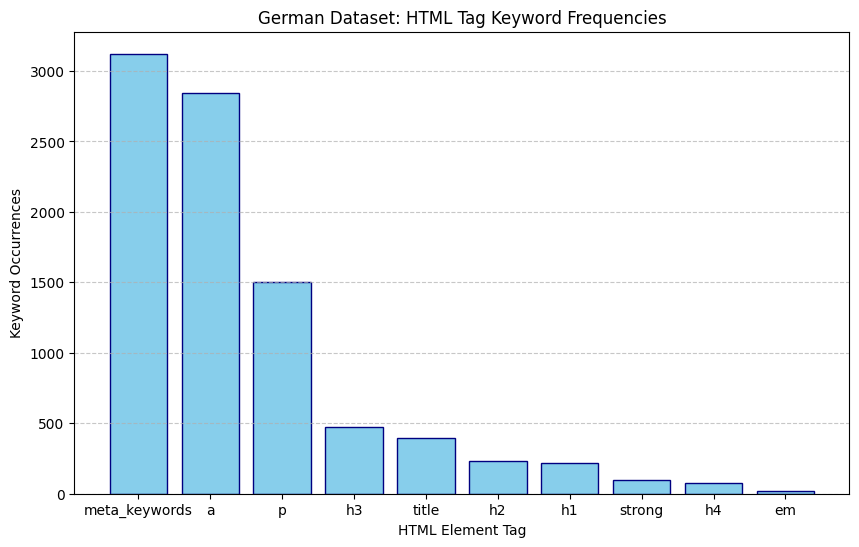

In [ ]:


# German dataset 


import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import warnings
from bs4 import XMLParsedAsHTMLWarning

# Suppress XML/HTML mismatch warnings
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

dataset_path = r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\german_dataset"
tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords"]

# --- Text Cleaning Function (Word Preprocessing) ---
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    # Removes punctuation but keeps German characters (ä, ö, ü, ß) and numbers
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    # Join and clean the text from HTML
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")

    count = 0
    for k in keywords:
        # Clean the keyword from GT.txt to ensure match
        k = clean_text(k)
        if k:
            # Use regex boundaries \b to match exact words only
            matches = re.findall(r'\b' + re.escape(k) + r'\b', combined_text)
            if debug and len(matches) > 0:
                print(f"   [Match] '{k}' found {len(matches)} times")
            count += len(matches)
    return count

total_tag_counts = {tag: 0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of German Dataset...\n")

for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    
    html_file = os.path.join(folder_path, "HTML.txt")  # German dataset filename
    tags_file = os.path.join(folder_path, "GT.txt")    # Ground-truth filename
    
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
        
    try:
        # 1. Read Keywords from GT.txt
        with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            # Handle different GT.txt formats (comma-separated or list)
            if "," in content:
                # If it follows your specific parts[1] logic:
                parts = content.split(None, 1)
                keywords = [k.strip() for k in parts[1].split(",") if k.strip()] if len(parts) > 1 else []
            else:
                keywords = [k.strip() for k in content.splitlines() if k.strip()]

        # 2. Read and Parse HTML.txt
        with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "html.parser") # Use html.parser for flexibility

        # Remove script and style elements (Cleaning JavaScript noise)
        for script_or_style in soup(["script", "style"]):
            script_or_style.decompose()

        tags_data = {
            "title": [soup.title.get_text()] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            "h2": [h.get_text() for h in soup.find_all("h2")],
            "h3": [h.get_text() for h in soup.find_all("h3")],
            "h4": [h.get_text() for h in soup.find_all("h4")],
            "p": [p.get_text() for p in soup.find_all("p")],
            "a": [a.get_text() for a in soup.find_all("a")],
            "strong": [s.get_text() for s in soup.find_all("strong")],
            "em": [e.get_text() for e in soup.find_all("em")],
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name": "keywords"})]
        }

        # Show cleaned words for the very first folder processed
        show_debug = True if processed_folders == 0 else False

        for tag in tags_to_check:
            total_tag_counts[tag] += count_keywords(tags_data[tag], keywords, tag, folder_name, debug=show_debug)
        
        if processed_folders == 0:
            input("\nReview the cleaned words above, then press Enter to finish the full analysis...")

        processed_folders += 1
        if processed_folders % 20 == 0:
            print(f"> {processed_folders} folders processed...")
            
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# --- Final Tabulation ---
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")
df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag", "Keyword Occurrences"])

if df["Keyword Occurrences"].sum() > 0:
    df["Percentage"] = (df["Keyword Occurrences"] / df["Keyword Occurrences"].sum()) * 100
    df = df.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    df["Importance Score"] = df["Keyword Occurrences"] / df["Keyword Occurrences"].max()
    
    print("\n" + df.to_string())
    
    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.bar(df["HTML Tag"], df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("German Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check GT.txt format or folder contents.")

In [ ]:

import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# Dataset paths
datasets = {
    "Macworld": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\macworld",
    "IndianExpress": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\indianexpress",
    "Kaksplus": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\kaksplus",
    "Uusisuomi": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\uusisuomi",
    "German": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\german_dataset"
}

tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords", "url_path"]

def clean_text(text):
    if not text: return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def count_keywords(combined_text, keywords):
    count = 0
    combined_text = clean_text(combined_text)
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean: continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        count += len(matches)
    return count

# All results
master_results = {tag: 0 for tag in tags_to_check}

for ds_name, ds_path in datasets.items():
    print(f"Analyzing {ds_name}...")
    
    for folder_name in os.listdir(ds_path):
        folder_full_path = os.path.join(ds_path, folder_name)
        if not os.path.isdir(folder_full_path): continue
        
        # Dosya isimleri veri setine göre değişebiliyor (Örn: German setinde HTML.txt/GT.txt)
        html_file = os.path.join(folder_full_path, "index.html") if ds_name != "German" else os.path.join(folder_full_path, "HTML.txt")
        tags_file = os.path.join(folder_full_path, "tags.txt") if ds_name != "German" else os.path.join(folder_full_path, "GT.txt")
        
        if not (os.path.exists(html_file) and os.path.exists(tags_file)): continue
        
        try:
            # 1. Read Keywords 
            with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().strip()
                
                if "," in content:
                    parts = content.split(None, 1)
                    keywords = [k.strip() for k in parts[1].split(",")] if len(parts) > 1 else []
                else:
                    keywords = content.splitlines()

            # 2. Read HTML 
            with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
                soup = BeautifulSoup(f.read(), "lxml")

            # 3. URL Analysis
            url_text = folder_name.replace("-", " ").replace("_", " ")
            master_results["url_path"] += count_keywords(url_text, keywords)

            # 4. Tag Analizi
            master_results["title"] += count_keywords(soup.title.get_text() if soup.title else "", keywords)
            master_results["h1"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h1")]), keywords)
            master_results["h2"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h2")]), keywords)
            master_results["h3"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h3")]), keywords)
            master_results["h4"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h4")]), keywords)
            master_results["p"] += count_keywords(" ".join([p.get_text() for p in soup.find_all("p")]), keywords)
            master_results["a"] += count_keywords(" ".join([a.get_text() for a in soup.find_all("a")]), keywords)
            master_results["strong"] += count_keywords(" ".join([s.get_text() for s in soup.find_all("strong")]), keywords)
            master_results["em"] += count_keywords(" ".join([e.get_text() for e in soup.find_all("em")]), keywords)
            
            # Meta keywords 
            meta_text = " ".join([m["content"] for m in soup.find_all("meta", attrs={"name": re.compile(r'keywords|tags', re.I)}) if m.has_attr("content")])
            master_results["meta_keywords"] += count_keywords(meta_text, keywords)

        except: continue

# Final table
df_final = pd.DataFrame(list(master_results.items()), columns=["HTML Tag", "Total Keyword Occurrences"])
df_final = df_final.sort_values(by="Total Keyword Occurrences", ascending=False)
df_final["Importance Score"] = df_final["Total Keyword Occurrences"] / df_final["Total Keyword Occurrences"].max()

print("\n--- MASTER ANALYSIS RESULT ---")
print(df_final.to_string())
df_final.to_csv("master_analysis_report.csv", index=False)

Analyzing Macworld...
Analyzing IndianExpress...
Analyzing Kaksplus...
Analyzing Uusisuomi...
Analyzing German...

--- MASTER ANALYSIS RESULT ---
         HTML Tag  Total Keyword Occurrences  Importance Score
6               a                      12725          1.000000
5               p                      11251          0.884165
9   meta_keywords                       8621          0.677485
0           title                       1270          0.099804
1              h1                       1111          0.087308
10       url_path                       1078          0.084715
2              h2                        945          0.074263
3              h3                        724          0.056896
7          strong                        519          0.040786
4              h4                        340          0.026719
8              em                        197          0.015481


Starting Global Tag-Level Analysis...
-> Analyzing Dataset: Macworld
-> Analyzing Dataset: IndianExpress
-> Analyzing Dataset: Kaksplus
-> Analyzing Dataset: Uusisuomi
-> Analyzing Dataset: German

MEMBER 2: FINAL TAG-LEVEL FREQUENCY REPORT
      HTML Tag  Keyword Occurrences  Percentage (%)  Importance Score
             a                12725           32.40              1.00
             p                11251           28.65              0.88
 meta_keywords                 9107           23.19              0.72
         title                 1271            3.24              0.10
            h1                 1111            2.83              0.09
url_components                 1078            2.75              0.08
            h2                  948            2.41              0.07
            h3                  724            1.84              0.06
        strong                  519            1.32              0.04
            h4                  340            0.87        

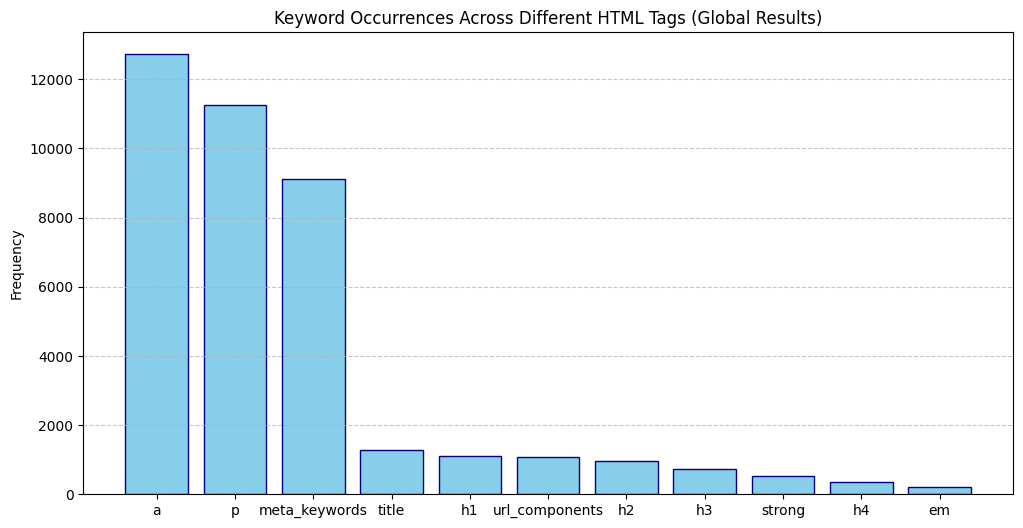

In [ ]:


import os
import re
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings
from bs4 import XMLParsedAsHTMLWarning

# 1. SETUP & CONFIGURATION
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

datasets = {
    "Macworld": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\macworld",
    "IndianExpress": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\indianexpress",
    "Kaksplus": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\kaksplus",
    "Uusisuomi": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\uusisuomi",
    "German": r"C:\Users\Koti\Desktop\Data analytics assignments\Datasets\german_dataset"
}

tags_to_track = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords", "url_components"]
master_results = {tag: 0 for tag in tags_to_track}

# 2. HELPER FUNCTIONS
def clean_text(text):
    """Clean text while preserving German/Finnish characters."""
    if not text: return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def count_keywords(text, keywords):
    """Counts exact occurrences of keywords in cleaned text."""
    if not text: return 0
    text_clean = clean_text(text)
    count = 0
    for kw in keywords:
        kw_clean = clean_text(kw)
        if not kw_clean: continue
        # Use word boundaries \b to ensure 'apple' doesn't match 'pineapple'
        matches = re.findall(r'\b' + re.escape(kw_clean) + r'\b', text_clean)
        count += len(matches)
    return count

# 3. PROCESSING ENGINE
print("Starting Global Tag-Level Analysis...")

for name, path in datasets.items():
    if not os.path.exists(path):
        print(f"Skipping: {name} (Path not found)")
        continue

    print(f"-> Analyzing Dataset: {name}")
    
    # Iterate through folders inside each dataset
    for folder_name in os.listdir(path):
        folder_path = os.path.join(path, folder_name)
        if not os.path.isdir(folder_path): continue

        # Flexible File Detection (Handles English/Finnish vs German naming)
        html_file = next((os.path.join(folder_path, f) for f in ["index.html", "HTML.txt"] 
                         if os.path.exists(os.path.join(folder_path, f))), None)
        
        kw_file = next((os.path.join(folder_path, f) for f in ["tags.txt", "GT.txt", "keywords.txt"] 
                       if os.path.exists(os.path.join(folder_path, f))), None)

        if not html_file or not kw_file: continue

        try:
            # Step A: Load Keywords
            with open(kw_file, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().strip()
                # Split logic: Keywords often come after a colon or as a simple list
                parts = content.split(None, 1)
                keywords = [k.strip() for k in parts[1].split(",") if k.strip()] if len(parts) > 1 else content.splitlines()

            # Step B: Parse HTML & Cleanup Noise
            with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
                soup = BeautifulSoup(f.read(), "html.parser")
            
            # Remove scripts/styles so JS code doesn't inflate results
            for script_or_style in soup(["script", "style"]):
                script_or_style.decompose()

            # Step C: Tag Extraction & Keyword Counting
            for tag in ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em"]:
                elements = soup.find_all(tag)
                text_content = " ".join([el.get_text() for el in elements])
                master_results[tag] += count_keywords(text_content, keywords)

            # Step D: Meta Tags (Keywords & Description)
            meta_tags = soup.find_all("meta", attrs={"name": re.compile(r'keywords|description', re.I)})
            meta_text = " ".join([m.get("content", "") for m in meta_tags if m.get("content")])
            master_results["meta_keywords"] += count_keywords(meta_text, keywords)

            # Step E: URL Analysis (Using folder names as slug proxy)
            url_slug = folder_name.replace("-", " ").replace("_", " ")
            master_results["url_components"] += count_keywords(url_slug, keywords)

        except:
            continue

# 4. REPORTING & VISUALIZATION
df_final = pd.DataFrame(list(master_results.items()), columns=["HTML Tag", "Keyword Occurrences"])
total_hits = df_final["Keyword Occurrences"].sum()

if total_hits > 0:
    df_final["Percentage (%)"] = (df_final["Keyword Occurrences"] / total_hits * 100).round(2)
    max_val = df_final["Keyword Occurrences"].max()
    df_final["Importance Score"] = (df_final["Keyword Occurrences"] / max_val).round(2)
    
    # Sort by frequency
    df_final = df_final.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    
    print("\n" + "="*50)
    print("MEMBER 2: FINAL TAG-LEVEL FREQUENCY REPORT")
    print("="*50)
    print(df_final.to_string(index=False))
    
    # Save to CSV
    df_final.to_csv("member2_tag_analysis_final.csv", index=False)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.bar(df_final["HTML Tag"], df_final["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.title("Keyword Occurrences Across Different HTML Tags (Global Results)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No keywords were found. Please check your dataset folder paths.")

In [ ]:
print("\n=== MASTER ANALYSIS: ALL DATASETS ===")

import os
import re
from bs4 import BeautifulSoup

# ────────────────────────────────────────────────────────────────
# YOUR MACOS PATHS – only change BASE if Datasets is somewhere else
# ────────────────────────────────────────────────────────────────
BASE = "/Users/rexogehenerobo/Downloads/Datasets"  # ← your main folder

datasets = {
    "Macworld": os.path.join(BASE, "macworld"),
    "IndianExpress": os.path.join(BASE, "indianexpress"),
    "Kaksplus": os.path.join(BASE, "kaksplus"),
    "Uusisuomi": os.path.join(BASE, "uusisuomi"),
    "German": os.path.join(BASE, "german_dataset")
}

TAGS = ['title', 'h1', 'h2', 'h3', 'h4', 'p', 'a', 'strong', 'em', 'meta_keywords', 'url_path']

master_results = {tag: 0 for tag in TAGS}
processed_count = {ds: 0 for ds in datasets}

# ────────────────────────────────────────────────────────────────
# HELPER: Clean text (same as before, but make sure it matches)
# ────────────────────────────────────────────────────────────────
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # remove punctuation
    return " ".join(text.split())

# ────────────────────────────────────────────────────────────────
# HELPER: Count keywords with word boundaries
# ────────────────────────────────────────────────────────────────
def count_keywords(text, keywords):
    if not text or not keywords:
        return 0
    clean = clean_text(text)
    total = 0
    for kw in keywords:
        kw_clean = clean_text(kw)
        if not kw_clean:
            continue
        pattern = r'\b' + re.escape(kw_clean) + r'\b'
        matches = re.findall(pattern, clean)
        total += len(matches)
    return total

# ────────────────────────────────────────────────────────────────
# MAIN LOOP: Process each dataset
# ────────────────────────────────────────────────────────────────
for ds_name, ds_path in datasets.items():
    if not os.path.exists(ds_path):
        print(f"WARNING: Path not found → {ds_path}")
        continue
    
    print(f"\nProcessing {ds_name}...")
    
    for folder_name in sorted(os.listdir(ds_path)):
        folder_full = os.path.join(ds_path, folder_name)
        if not os.path.isdir(folder_full):
            continue
        
        # Flexible file names
        html_file = 'index.html' if ds_name != 'German' else 'HTML.txt'
        tags_file_name = 'tags.txt' if ds_name != 'German' else 'GT.txt'
        
        html_path = os.path.join(folder_full, html_file)
        tags_path = os.path.join(folder_full, tags_file_name)
        
        if not (os.path.exists(html_path) and os.path.exists(tags_path)):
            continue
        
        try:
            # ─── ROBUST KEYWORD READING ───
            with open(tags_path, "r", encoding="utf-8", errors="ignore") as f:
                raw = f.read().strip().lower()
                # Remove leading number + optional space/comma
                raw = re.sub(r'^\d+[\s,]*', '', raw).strip()
                
                # Split logic: comma > newline > space
                if ',' in raw:
                    kws = [k.strip() for k in raw.split(',') if k.strip()]
                else:
                    kws = [k.strip() for k in re.split(r'[\s\n]+', raw) if k.strip()]
                
                keywords = list(set(kws))  # remove duplicates
                
                # Always show what was parsed
                print(f"[{ds_name}] {folder_name} → {len(keywords)} keywords: {keywords[:10]}{'...' if len(keywords)>10 else ''}")
                
                if not keywords:
                    print("  → No keywords parsed - skipping")
                    continue

            # Parse HTML
            with open(html_path, "r", encoding="utf-8", errors="ignore") as f:
                soup = BeautifulSoup(f.read(), "html.parser")
            
            for script_or_style in soup(["script", "style"]):
                script_or_style.decompose()

            # Extract tag texts
            tag_texts = {
                'title': soup.title.string if soup.title else "",
                'h1': ' '.join(h.get_text() for h in soup.find_all('h1')),
                'h2': ' '.join(h.get_text() for h in soup.find_all('h2')),
                'h3': ' '.join(h.get_text() for h in soup.find_all('h3')),
                'h4': ' '.join(h.get_text() for h in soup.find_all('h4')),
                'p':   ' '.join(p.get_text() for p in soup.find_all('p')),
                'a':   ' '.join(a.get_text() for a in soup.find_all('a')),
                'strong': ' '.join(s.get_text() for s in soup.find_all('strong')),
                'em':  ' '.join(e.get_text() for e in soup.find_all('em')),
                'meta_keywords': ' '.join(m.get('content', '') for m in soup.find_all('meta', attrs={'name': re.compile('keywords|description', re.I)})),
                'url_path': folder_name.replace('-', ' ').replace('_', ' ')
            }

            # Count matches
            for tag, text in tag_texts.items():
                count = count_keywords(text, keywords)
                master_results[tag] += count
                if count > 0:
                    print(f"  {tag}: {count} matches found")

            processed_count[ds_name] += 1

        except Exception as e:
            print(f"Error in {ds_name}/{folder_name}: {e}")
            continue
    
    print(f"  → {processed_count[ds_name]} articles processed")

# ────────────────────────────────────────────────────────────────
# SUMMARY & ZERO CHECK
# ────────────────────────────────────────────────────────────────
print("\n=== SUMMARY ===")
total = sum(processed_count.values())
for ds, cnt in processed_count.items():
    print(f"{ds:14} {cnt} articles")
print(f"TOTAL: {total} articles")

if sum(master_results.values()) == 0:
    print("\nWARNING: ALL COUNTS ARE ZERO – check keyword parsing or file contents")
else:
    print("\nSuccess: Non-zero counts detected!")
    # Optional: print top results for quick check
    sorted_results = sorted(master_results.items(), key=lambda x: x[1], reverse=True)
    print("Top 5 tags:", sorted_results[:5])